In [1]:
# # 이미지 유사도 분석 모델 다운로드
# !wget -O embedder.tflite -q https://storage.googleapis.com/mediapipe-models/image_embedder/mobilenet_v3_small/float32/1/mobilenet_v3_small.tflite
# !wget https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite

In [2]:
import urllib

IMAGE_FILENAMES = ['burger.jpg', 'burger_crop.jpg']

for name in IMAGE_FILENAMES:
  url = f'https://storage.googleapis.com/mediapipe-assets/{name}'
  urllib.request.urlretrieve(url, name)

burger.jpg


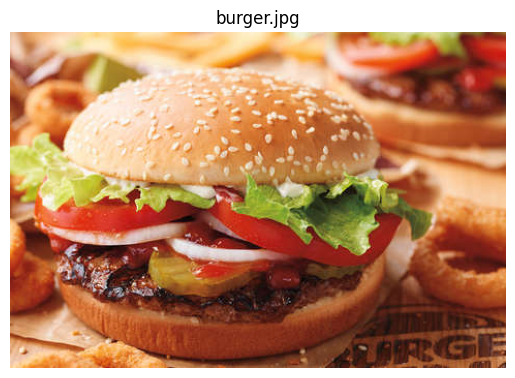

burger_crop.jpg


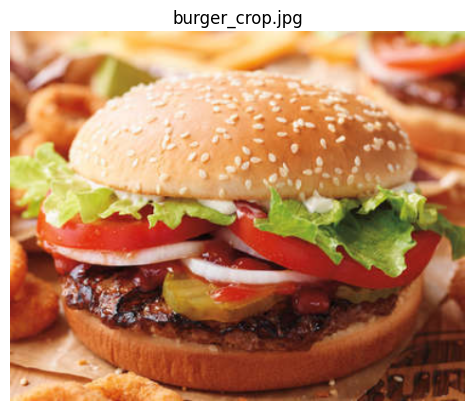

In [3]:
import cv2
import math
import matplotlib.pyplot as plt

DESIRED_HEIGHT = 480
DESIRED_WIDTH = 480

def resize_and_show(image):
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (DESIRED_WIDTH, math.floor(h/(w/DESIRED_WIDTH))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/DESIRED_HEIGHT)), DESIRED_HEIGHT))
    return(img)


# Preview the images.
images = {name: cv2.imread(name) for name in IMAGE_FILENAMES}
for name, image in images.items():
    print(name)
    resized_image = resize_and_show(image)
    plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
    plt.title(name)
    plt.axis('off')
    plt.show()
    

In [4]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Create options for Image Embedder
base_options = python.BaseOptions(model_asset_path='embedder.tflite')
l2_normalize = True #@param {type:"boolean"}
quantize = True #@param {type:"boolean"}
options = vision.ImageEmbedderOptions(
    base_options=base_options, l2_normalize=l2_normalize, quantize=quantize)


# Create Image Embedder
with vision.ImageEmbedder.create_from_options(options) as embedder:

    # Format images for MediaPipe
    first_image = mp.Image.create_from_file(IMAGE_FILENAMES[0])
    second_image = mp.Image.create_from_file(IMAGE_FILENAMES[1])
    first_embedding_result = embedder.embed(first_image)
    second_embedding_result = embedder.embed(second_image)

    # Calculate and print similarity
    similarity = vision.ImageEmbedder.cosine_similarity(
      first_embedding_result.embeddings[0],
      second_embedding_result.embeddings[0])
    print(similarity)

0.9154104779706991


# 미디어 파이프 모델로 얼굴 유사도 판별하기
* 사진 2장 필요
* 사진에서 얼굴 찾기 - 얼굴 찾는 모델
* 얼굴만 크롭
* 얼굴을 숫자로 임베딩 - 이미지를 숫자로 벡터화(임베딩)하는 모델
* 임베딩 된 얼굴을 비교
* 유사도 출력
* 간단한 서비스 구현을 위해 gradio라이브러리 활용

In [5]:
import cv2
import numpy as np
import gradio as gr
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [6]:
# 얼굴 crop 함수
def crop_face(image_np):
    """
    image_np: Gradio에서 받은 RGB numpy array (H, W, C)
    """
    if image_np is None:
        return None
    
    if image_np.dtype != np.uint8:
        image_np = image_np.astype(np.uint8)
        
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)
    
    detection_result = face_detector.detect(mp_image)
    
    if not detection_result.detections:
        return None
    
    det = detection_result.detections[0]
    bbox = det.bounding_box
    
    x = max(0, bbox.origin_x)
    y = max(0, bbox.origin_y)
    w = bbox.width
    h = bbox.height
    
    x2 = min(image_np.shape[1], x + w)
    y2 = min(image_np.shape[0], y + h)
    
    face = image_np[y:y2, x:x2]
    
    if face.size == 0:
        return None
    
    return face

In [7]:
# 모델, embedder생성
embed_model_path = "./mobilenet_v3_large.tflite"
face_detect_model_path = "./blaze_face_short_range.tflite" 

# embedder생성
embed_base_options = python.BaseOptions(model_asset_path=embed_model_path)
embed_options = vision.ImageEmbedderOptions(
    base_options=embed_base_options, l2_normalize=True, quantize=True)

# Create Image Embedder
embedder = vision.ImageEmbedder.create_from_options(embed_options)

# face detector 생성
face_base_options = python.BaseOptions(model_asset_path=face_detect_model_path)
face_options = vision.FaceDetectorOptions(
    base_options=face_base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5)

# Create face detector
face_detector = vision.FaceDetector.create_from_options(face_options)

In [8]:
# 얼굴 유사도 비교 함수 작성
def image_sim(image1, image2):
    if image1 is None or image2 is None:
        return "이미지를 두 장 모두 업로드하세요", None, None
    
    img1 = np.array(image1)
    img2 = np.array(image2)
    
    face1 = crop_face(img1)
    face2 = crop_face(img2)
    
    if face1 is None or face2 is None:
        return "얼굴 감지 실패", None, None
    
    # 얼굴 crop 결과 확인
    face1_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=face1)
    face2_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=face2)
    
    emb1 = embedder.embed(face1_mp).embeddings[0]
    emb2 = embedder.embed(face2_mp).embeddings[0]
    
    similarity = vision.ImageEmbedder.cosine_similarity(emb1, emb2)
    
    return f"얼굴 유사도: {similarity:.4f}", face1, face2

# gradio를 이용해서 UI및 간이 서버 만들기
* 내부적으로 fastapi 사용: 웹서버

In [11]:
with gr.Blocks() as app:
    gr.Markdown("## 얼굴 유사도 비교")
    
    # 이미지 업로더
    with gr.Row():
        image1 = gr.Image(label="First Image", type="numpy")
        image2 = gr.Image(label="Second Image", type="numpy")
        
    # 크롭 결과 확인
    with gr.Row():
        face1_out = gr.Image(label='Croped Face1')
        face2_out = gr.Image(label='Croped Face2')
        
    output_text = gr.Textbox(label='결과')
    
    convert_btn = gr.Button("유사도 비교하기")
    
    convert_btn.click(
            fn=image_sim,
            inputs=[image1, image2],
            outputs=[output_text, face1_out, face2_out])

app.launch(inline=False, share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [12]:
app.close()

Closing server running on port: 7860
